In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("student_database.db")
cursor = conn.cursor()
print("Database connected successfully!")

Database connected successfully!


In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS students (
    student_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    age INTEGER,
    gender TEXT,
    course TEXT,
    marks INTEGER,
    attendance REAL,
    grade TEXT)
""")

conn.commit()

print("Students table created successfully!")

Students table created successfully!


In [7]:
import random

names = [
    "Ananya", "Rahul", "Sneha", "Arjun", "Priya",
    "Kiran", "Divya", "Vikram", "Meena", "Ravi",
    "Sanjay", "Pooja", "Akhil", "Swathi", "Rohit",
    "Kavya", "Varun", "Neha", "Manoj", "Aishwarya"
]

courses = ["Python", "SQL", "Data Analytics", "Power BI"]

students = []

for i in range(1, 101):
    name = random.choice(names) + "_" + str(i)
    age = random.randint(18, 23)
    gender = random.choice(["Male", "Female"])
    course = random.choice(courses)
    marks = random.randint(40, 100)
    attendance = round(random.uniform(60, 100), 1)

    if marks >= 80:
        grade = "A"
    elif marks >= 60:
        grade = "B"
    elif marks >= 50:
        grade = "C"
    else:
        grade = "D"

    students.append(
        (i, name, age, gender, course, marks, attendance, grade)
    )

cursor.executemany("""
INSERT OR IGNORE INTO students
(student_id, name, age, gender, course, marks, attendance, grade)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
""", students)

conn.commit()

print("100 student records inserted successfully!")

100 student records inserted successfully!


In [9]:
query = "SELECT * FROM students"

df = pd.read_sql_query(query, conn)

print("Total students:", len(df))

df

Total students: 100


,student_id,name,age,gender,course,marks,attendance,grade
0,1,Ananya,20,Female,Python,85,92.0,A
1,2,Rahul,21,Male,Python,72,85.0,B
2,3,Sneha,20,Female,SQL,91,95.0,A
3,4,Arjun,22,Male,SQL,65,78.0,C
4,5,Priya,21,Female,Python,88,90.0,A
...,...,...,...,...,...,...,...,...
95,96,Sneha_96,19,Male,Data Analytics,45,84.6,D
96,97,Priya_97,18,Female,Data Analytics,83,68.1,A
97,98,Aishwarya_98,18,Female,Python,96,70.8,A
98,99,Meena_99,19,Male,Data Analytics,67,78.7,B


In [10]:
query = """
SELECT student_id, name, course, marks, attendance, grade
FROM students
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,marks,attendance,grade
0,1,Ananya,Python,85,92.0,A
1,2,Rahul,Python,72,85.0,B
2,3,Sneha,SQL,91,95.0,A
3,4,Arjun,SQL,65,78.0,C
4,5,Priya,Python,88,90.0,A
...,...,...,...,...,...,...
95,96,Sneha_96,Data Analytics,45,84.6,D
96,97,Priya_97,Data Analytics,83,68.1,A
97,98,Aishwarya_98,Python,96,70.8,A
98,99,Meena_99,Data Analytics,67,78.7,B


In [11]:
query = """
SELECT student_id, name, course, marks, grade
FROM students
WHERE marks > 80
ORDER BY marks DESC
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,marks,grade
0,48,Rohit_48,SQL,99,A
1,70,Varun_70,Python,99,A
2,27,Varun_27,SQL,98,A
3,68,Neha_68,Power BI,97,A
4,94,Vikram_94,Data Analytics,97,A
5,98,Aishwarya_98,Python,96,A
6,38,Ravi_38,Data Analytics,95,A
7,65,Sneha_65,SQL,95,A
8,8,Vikram,Python,93,A
9,36,Ravi_36,SQL,93,A


In [12]:
query = """
SELECT student_id, name, course, attendance
FROM students
WHERE attendance > 85
ORDER BY attendance DESC
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,attendance
0,87,Ananya_87,SQL,99.7
1,70,Varun_70,Python,99.5
2,63,Rohit_63,Data Analytics,99.3
3,92,Neha_92,Data Analytics,99.3
4,94,Vikram_94,Data Analytics,98.7
5,15,Kavya_15,Data Analytics,98.0
6,40,Vikram_40,SQL,98.0
7,79,Sneha_79,Data Analytics,97.2
8,82,Sanjay_82,Data Analytics,97.0
9,30,Divya_30,SQL,96.9


In [13]:
query = """
SELECT student_id, name, course, marks, grade
FROM students
ORDER BY marks DESC
LIMIT 10
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,marks,grade
0,48,Rohit_48,SQL,99,A
1,70,Varun_70,Python,99,A
2,27,Varun_27,SQL,98,A
3,68,Neha_68,Power BI,97,A
4,94,Vikram_94,Data Analytics,97,A
5,98,Aishwarya_98,Python,96,A
6,38,Ravi_38,Data Analytics,95,A
7,65,Sneha_65,SQL,95,A
8,8,Vikram,Python,93,A
9,36,Ravi_36,SQL,93,A


In [14]:
query = """
SELECT AVG(marks) AS average_marks
FROM students
"""

df = pd.read_sql_query(query, conn)

df

,average_marks
0,73.09


In [15]:
query = """
SELECT MAX(marks) AS highest_marks
FROM students
"""

df = pd.read_sql_query(query, conn)

df

,highest_marks
0,99


In [16]:
query = """
SELECT MIN(marks) AS lowest_marks
FROM students
"""

df = pd.read_sql_query(query, conn)

df

,lowest_marks
0,41


In [18]:
query = """
SELECT course, COUNT(*) AS number_of_students
FROM students
GROUP BY course
"""

df = pd.read_sql_query(query, conn)

df

,course,number_of_students
0,Data Analytics,25
1,Power BI,19
2,Python,29
3,SQL,27


In [19]:
query = """
SELECT course, ROUND(AVG(marks), 2) AS average_marks
FROM students
GROUP BY course
ORDER BY average_marks DESC
"""

df = pd.read_sql_query(query, conn)

df

,course,average_marks
0,Power BI,73.63
1,Python,73.62
2,SQL,73.00
3,Data Analytics,72.16


In [20]:
query = """
SELECT grade, COUNT(*) AS number_of_students
FROM students
GROUP BY grade
ORDER BY grade
"""

df = pd.read_sql_query(query, conn)

df

,grade,number_of_students
0,A,33
1,B,47
2,C,10
3,D,10


In [21]:
query = """
SELECT student_id, name, course, marks, attendance
FROM students
WHERE marks < 50
ORDER BY marks
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,marks,attendance
0,14,Akhil_14,Python,41,94.8
1,83,Kavya_83,SQL,41,82.8
2,19,Kavya_19,Data Analytics,43,63.2
3,75,Ananya_75,Data Analytics,44,74.2
4,21,Kiran_21,Python,45,74.6
5,96,Sneha_96,Data Analytics,45,84.6
6,52,Divya_52,Power BI,49,62.3
7,55,Varun_55,Power BI,49,70.5
8,59,Ananya_59,Python,49,81.3


In [22]:
query = """
SELECT student_id, name, course, attendance
FROM students
WHERE attendance < 75
ORDER BY attendance
"""

df = pd.read_sql_query(query, conn)

df

,student_id,name,course,attendance
0,39,Arjun_39,SQL,60.2
1,78,Aishwarya_78,Data Analytics,60.6
2,17,Arjun_17,Data Analytics,60.9
3,46,Akhil_46,Data Analytics,61.3
4,31,Arjun_31,Power BI,62.2
5,52,Divya_52,Power BI,62.3
6,74,Varun_74,Power BI,63.1
7,19,Kavya_19,Data Analytics,63.2
8,23,Swathi_23,Power BI,63.2
9,43,Vikram_43,Data Analytics,63.4


In [23]:
query = """
SELECT gender, COUNT(*) AS number_of_students
FROM students
GROUP BY gender
"""

df = pd.read_sql_query(query, conn)

df

,gender,number_of_students
0,Female,47
1,Male,53


In [24]:
student_name = input("Enter student name: ")

query = """
SELECT *
FROM students
WHERE name LIKE ?
"""

df = pd.read_sql_query(query, conn, params=(f"%{student_name}%",))

df

Enter student name:  Ananya


,student_id,name,age,gender,course,marks,attendance,grade
0,1,Ananya,20,Female,Python,85,92.0,A
1,11,Ananya_11,19,Male,Python,91,84.6,A
2,59,Ananya_59,18,Male,Python,49,81.3,D
3,75,Ananya_75,20,Female,Data Analytics,44,74.2,D
4,80,Ananya_80,21,Female,Python,74,66.4,B
5,87,Ananya_87,20,Female,SQL,52,99.7,C


In [25]:
student_id = int(input("Enter student ID: "))
new_marks = int(input("Enter new marks: "))

cursor.execute("""
UPDATE students
SET marks = ?
WHERE student_id = ?
""", (new_marks, student_id))

conn.commit()

print("Marks updated successfully!")

Enter student ID:  1
Enter new marks:  47


Marks updated successfully!


In [26]:
student_id = int(input("Enter student ID to delete: "))

cursor.execute("""
DELETE FROM students
WHERE student_id = ?
""", (student_id,))

conn.commit()

print("Student deleted successfully!")

Enter student ID to delete:  1


Student deleted successfully!


In [27]:
query = """
SELECT COUNT(*) AS total_students
FROM students
"""

df = pd.read_sql_query(query, conn)

df

,total_students
0,99


In [28]:
query = """
SELECT
    COUNT(*) AS total_students,
    ROUND(AVG(marks), 2) AS average_marks,
    MAX(marks) AS highest_marks,
    MIN(marks) AS lowest_marks,
    ROUND(AVG(attendance), 2) AS average_attendance
FROM students
"""

summary = pd.read_sql_query(query, conn)

summary

,total_students,average_marks,highest_marks,lowest_marks,average_attendance
0,99,72.97,99,41,80.22


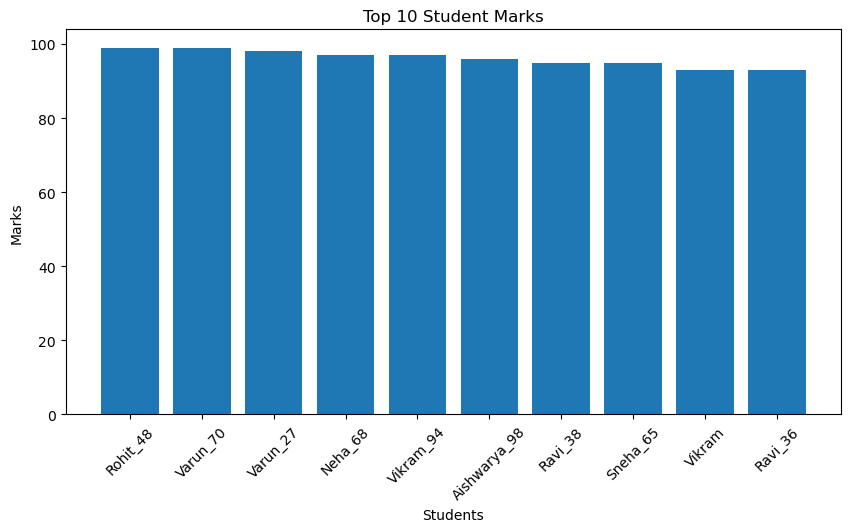

In [29]:
import matplotlib.pyplot as plt

query = """
SELECT name, marks
FROM students
ORDER BY marks DESC
LIMIT 10
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 5))
plt.bar(df["name"], df["marks"])

plt.xlabel("Students")
plt.ylabel("Marks")
plt.title("Top 10 Student Marks")

plt.xticks(rotation=45)
plt.show()

In [30]:
conn.close()

print("Database connection closed successfully!")

Database connection closed successfully!
